In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
def circle_map(theta, Omega, K):
    return theta + Omega - (K / (2 * np.pi)) * np.sin(2 * np.pi * theta)

In [6]:
N_SITES = 100
K_PARAM = 1.0
HEATMAP_STEPS = 200      
HEATMAP_OMEGA = 0.618 
HEATMAP_EPS = 0.4
theta = np.random.rand(N_SITES)
history = np.zeros((HEATMAP_STEPS, N_SITES))

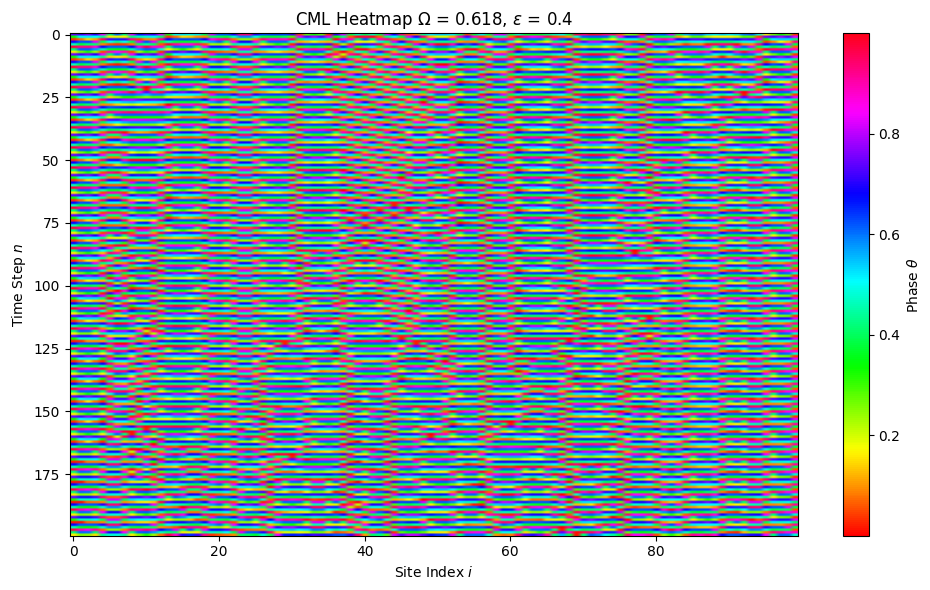

In [8]:
 
for t in range(HEATMAP_STEPS):
    history[t, :] = theta
    f_theta = circle_map(theta, HEATMAP_OMEGA, K_PARAM)
    coupled_theta = (1 - HEATMAP_EPS) * f_theta + (HEATMAP_EPS / 2.0) * (np.roll(f_theta, 1) + np.roll(f_theta, -1))
    theta = coupled_theta % 1.0 
plt.figure(figsize=(10, 6))
plt.imshow(history, aspect='auto', cmap='hsv', origin='upper') 
plt.colorbar(label='Phase $\\theta$')
plt.title(f"CML Heatmap $\\Omega$ = {HEATMAP_OMEGA}, $\\epsilon$ = {HEATMAP_EPS}")
plt.xlabel("Site Index $i$")
plt.ylabel("Time Step $n$")
plt.tight_layout()
plt.show()

Removing transients and then solving 

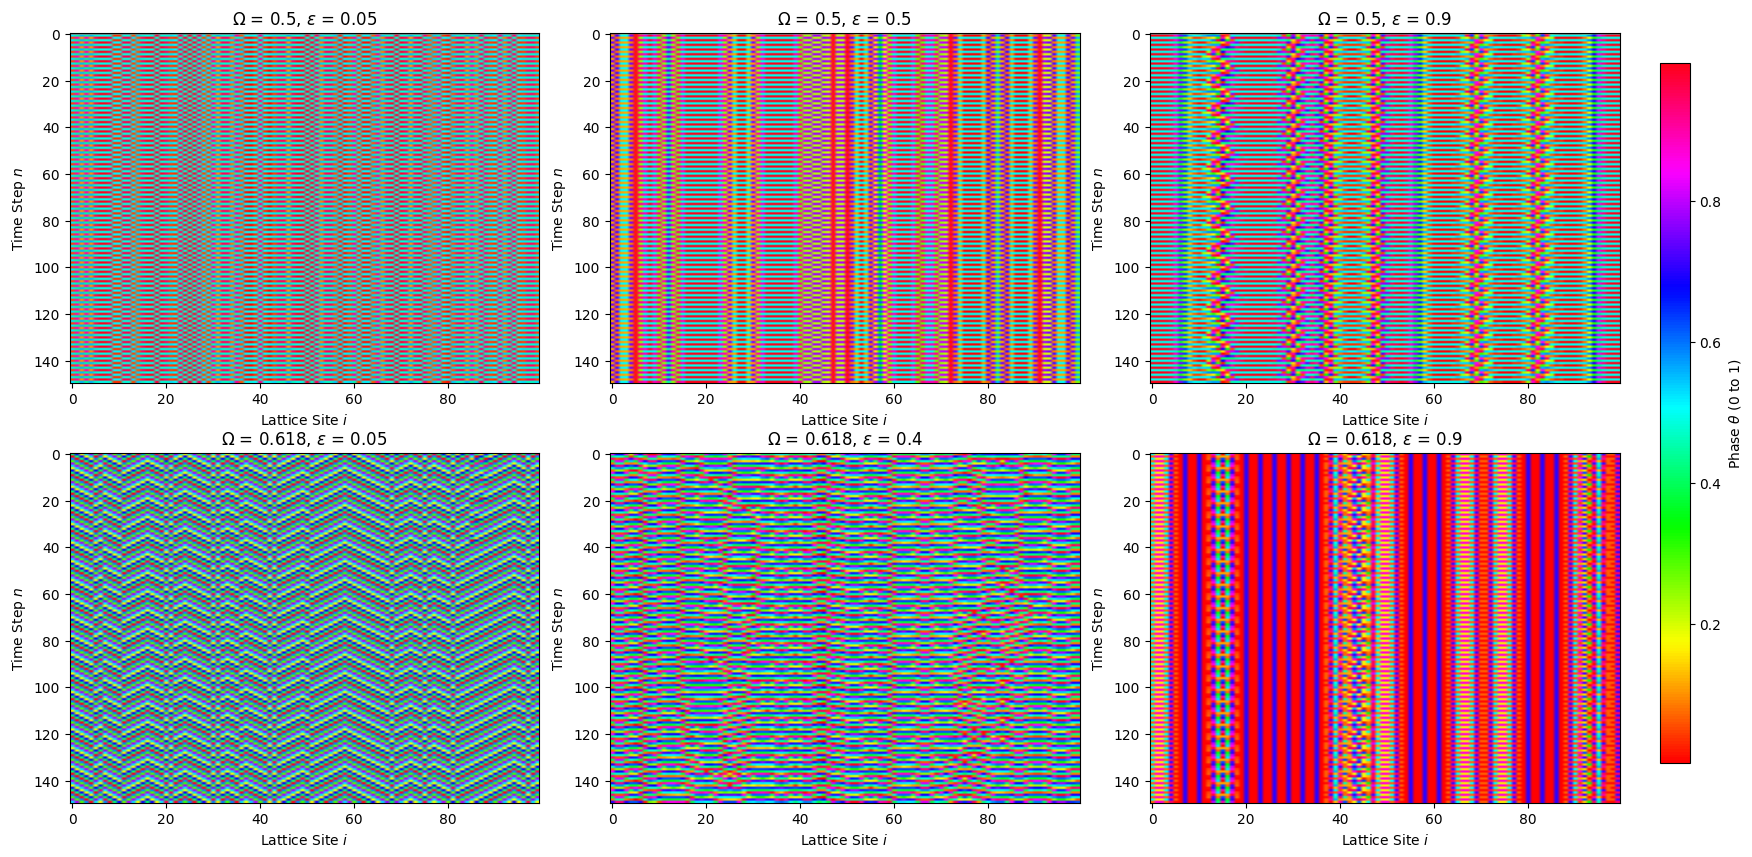

In [18]:
def run_circle_cml(Omega, epsilon, transients=200, record_steps=150, N=100, K=1.0):
    theta = np.random.rand(N)
    history = np.zeros((record_steps, N))
    
    for _ in range(transients):
        f_theta = circle_map(theta, Omega, K)
        coupled = (1 - epsilon) * f_theta + (epsilon / 2.0) * (np.roll(f_theta, 1) + np.roll(f_theta, -1))
        theta = coupled % 1.0
        
    for t in range(record_steps):
        history[t, :] = theta
        f_theta = circle_map(theta, Omega, K)
        coupled = (1 - epsilon) * f_theta + (epsilon / 2.0) * (np.roll(f_theta, 1) + np.roll(f_theta, -1))
        theta = coupled % 1.0
        
    return history

experiments = [
    {"Omega": 0.500, "epsilon": 0.05},
    {"Omega": 0.500, "epsilon": 0.50},
    {"Omega": 0.500, "epsilon": 0.90},
    {"Omega": 0.618, "epsilon": 0.05},
    {"Omega": 0.618, "epsilon": 0.40},
    {"Omega": 0.618, "epsilon": 0.90}
]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, exp in enumerate(experiments):
    data = run_circle_cml(Omega=exp["Omega"], epsilon=exp["epsilon"])
    ax = axes[i]
    im = ax.imshow(data, aspect='auto', cmap='hsv', origin='upper')
    ax.set_title(f"$\\Omega$ = {exp['Omega']}, $\\epsilon$ = {exp['epsilon']}")
    ax.set_xlabel("Lattice Site $i$")
    ax.set_ylabel("Time Step $n$")

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Phase $\\theta$ (0 to 1)')

plt.subplots_adjust(right=0.9, hspace=0.2, wspace=0.15)
plt.show()

### Characterization, Visualization, and Analysis of Numerics
The numeric simulation above explores the spatiotemporal dynamics of a 1D Coupled Map Lattice using the Sine Circle Map. As per the problem parameters, the non-linearity is fixed at the critical edge **$K = 1.0$**. The exploration focuses on the interplay between the driving frequency ($\Omega$) and the spatial coupling strength ($\epsilon$).

The plot grid above consists of 6 panels arranged in 2 rows and 3 columns. The top row analyzes a **Rational Drive ($\Omega = 0.5$)**, while the bottom row analyzes an **Irrational Drive ($\Omega = 0.618$, the Golden Ratio)**. Coupling strength ($\epsilon$) increases from left to right.

#### Top Row: Rational Drive ($\Omega = 0.5$)
When the driving frequency is a rational fraction, the phases naturally tend to lock into discrete, repeating patterns (Mode-Locking) over time.

* **Top-Left ($\epsilon = 0.05$):** At weak coupling, individual sites oscillate almost independently between two phases (due to the 1/2 drive). The lattice shows a fragmented, independent checkerboard pattern as local sites mode-lock without communicating globally.
* **Top-Center ($\epsilon = 0.50$):** As coupling increases, neighboring sites exert spatial "peer pressure." The fragmented checkerboards begin to merge into larger, synchronized clusters. The system exhibits local spatiotemporal synchronization.
* **Top-Right ($\epsilon = 0.90$):** At maximum coupling, spatial diffusion dominates the system. The entire 1D lattice perfectly synchronizes its phase, resulting in absolute global period-2 oscillation (beating uniformly across the entire spatial domain).

#### Bottom Row: Irrational Drive ($\Omega = 0.618$)
When the driving frequency is irrational, the uncoupled phases will never perfectly repeat, leading to quasiperiodic drift rather than clean mode-locking.

* **Bottom-Left ($\epsilon = 0.05$):** With weak coupling, the quasiperiodic nature dominates. The phases drift across the lattice, creating diagonal, "wind-like" streaks in the spacetime plot. There is no temporal periodicity.
* **Bottom-Center ($\epsilon = 0.40$):** At moderate coupling, the competition between irrational temporal drift and spatial nearest-neighbor synchronization creates full **spatiotemporal chaos**. Neighboring sites continually adjust their phases, resulting in complex, non-repeating "blob" structures and defect formations.
* **Bottom-Right ($\epsilon = 0.90$):** Even under an irrational drive, extreme coupling strength forces the chaotic lattice into submission. The entire lattice locks into a single phase that shifts uniformly over time, appearing as solid horizontal bands. The spatial degrees of freedom are completely eliminated by the strong diffusive coupling.

### Polar Plots

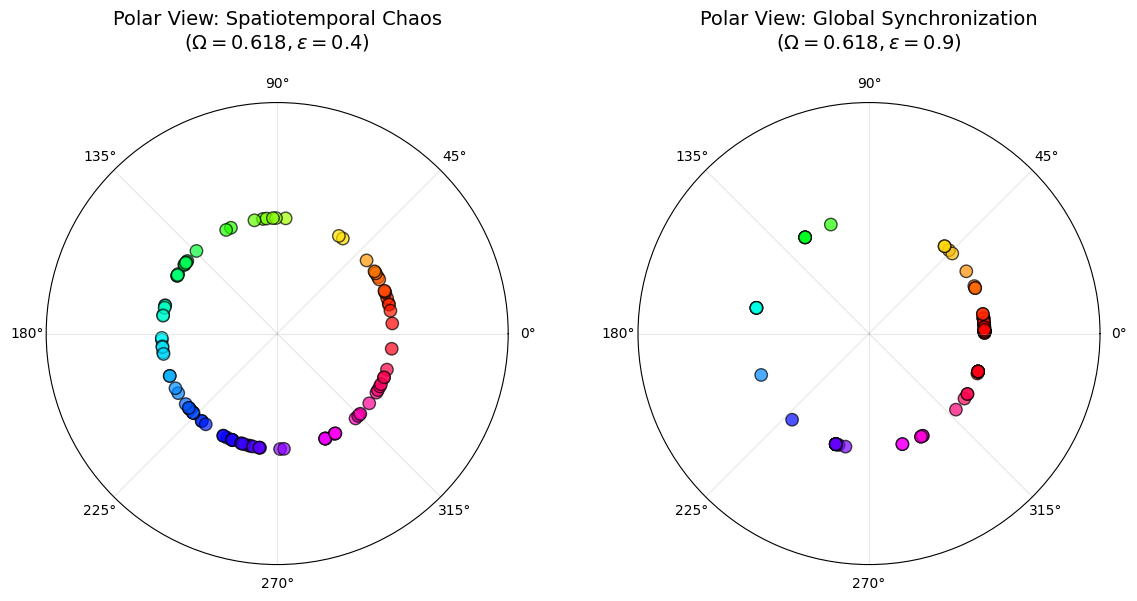

In [26]:
data_chaos = run_circle_cml(Omega=0.618, epsilon=0.40)  # Chaos
data_sync  = run_circle_cml(Omega=0.618, epsilon=0.90)  # Synchronized

final_chaos = data_chaos[-1, :] 
final_sync  = data_sync[-1, :]

# Convert phase (0 to 1) into radians (0 to 2*pi) for the polar plot
angles_chaos = final_chaos * 2 * np.pi
angles_sync  = final_sync * 2 * np.pi

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': 'polar'})
ax1.scatter(angles_chaos, np.ones(100), c=final_chaos, cmap='hsv', s=80, alpha=0.7, edgecolor='black')
ax1.set_title("Polar View: Spatiotemporal Chaos\n($\\Omega=0.618, \\epsilon=0.4$)", pad=20, fontsize=14)
ax1.set_yticks([])
ax1.grid(alpha=0.3)
ax2.scatter(angles_sync, np.ones(100), c=final_sync, cmap='hsv', s=80, alpha=0.7, edgecolor='black')
ax2.set_title("Polar View: Global Synchronization\n($\\Omega=0.618, \\epsilon=0.9$)", pad=20, fontsize=14)
ax2.set_yticks([])
ax2.grid(alpha=0.3)

plt.show()

### Polar Phase Analysis
To further characterize the spatial states of the lattice, the final time step ($n=150$) of the Sine Circle Map is projected onto a polar coordinate system. This effectively maps the 1D spatial ring onto the phase circle, where the angle represents the phase $\theta \in [0, 1]$.

* **Left Panel (Spatiotemporal Chaos, $\epsilon=0.4$):** At moderate coupling, the oscillators are distributed widely across the entire phase circle. This lack of clustering visually confirms the chaotic desynchronization of the lattice.
* **Right Panel (Global Synchronization, $\epsilon=0.9$):** Under extreme spatial coupling, the spatial degrees of freedom collapse. All 100 oscillators merge into a single, tight phase cluster, definitively proving the transition to complete global phase synchronization despite the irrational driving frequency.

### Conclusion
In this module, we explored the rich spatiotemporal dynamics of a 1D Coupled Map Lattice utilizing the Sine Circle Map. By fixing the nonlinearity parameter at the critical edge ($K=1.0$), the system's macroscopic behavior was entirely governed by the interplay between the internal driving frequency ($\Omega$) and the spatial coupling strength ($\epsilon$).

Our numerical explorations demonstrate two distinct routes of behavior:
1. **Rational Driving ($\Omega = 0.5$):** The system naturally favors discrete mode-locking. As spatial coupling increases, local fragmented periodicities merge, smoothly transitioning the lattice into global period-2 synchronization.
2. **Irrational Driving ($\Omega = 0.618$):** The system resists periodicity, favoring quasiperiodic drift. The competition between this temporal drift and spatial "peer pressure" generates complex spatiotemporal chaos at moderate coupling, eventually surrendering to forced global synchronization only at extreme coupling strengths.

Ultimately, this exploration highlights the universal competition between local temporal dynamics and global spatial diffusion in coupled non-linear oscillator networks.